In [1]:
from assignment2 import *

C:\Users\vince\Desktop\School\Graz\2026_S\CMSS\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
N_AGENTS = 1000
N_RUNS = 20
N_OBJECTS = 2
WORD_LENGTH = 5

single_data, all_runs_data, max_steps = run_multiple_times(N_RUNS, N_AGENTS, 1)
single_data_two, all_runs_data_two, max_steps_two = run_multiple_times(N_RUNS, N_AGENTS, 2)
single_data_five, all_runs_data_five, max_steps_five = run_multiple_times(N_RUNS, N_AGENTS, 5)
single_data_ten, all_runs_data_ten, max_steps_ten = run_multiple_times(N_RUNS, N_AGENTS, 10)

Computing single run...
Computing 20 runs for the ensemble average...
Computing single run...
Computing 20 runs for the ensemble average...
Computing single run...
Computing 20 runs for the ensemble average...
Computing single run...
Computing 20 runs for the ensemble average...


In [7]:
avg_nw , avg_nd ,avg_s = count_averages(all_runs_data, max_steps,n_runs= N_RUNS, n_objects=1,n_agents=N_AGENTS)
avg_nw_two , avg_nd_two ,avg_s_two = count_averages(all_runs_data_two, max_steps_two,n_runs= N_RUNS, n_objects=2,n_agents=N_AGENTS)
avg_nw_five , avg_nd_five ,avg_s_five = count_averages(all_runs_data_five, max_steps_five,n_runs= N_RUNS, n_objects=5,n_agents=N_AGENTS)
avg_nw_ten , avg_nd_ten ,avg_s_ten = count_averages(all_runs_data_ten, max_steps_ten,n_runs= N_RUNS, n_objects=10,n_agents=N_AGENTS)

In [8]:
def plot_multiple_objects_averages(averages_dict):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Generate a distinct color for each object count
    colors = sns.color_palette("husl", len(averages_dict))

    for idx, (n_objs, (nw, nd, s)) in enumerate(averages_dict.items()):
        color = colors[idx]
        label = f'{n_objs} Object{"s" if n_objs > 1 else ""}'

        axes[0].plot(nw, color=color, linewidth=2, label=label)

        axes[1].plot(nd, color=color, linewidth=2)

        smoothed_s = pd.Series(s).rolling(window=500, min_periods=1).mean()
        axes[2].plot(smoothed_s, color=color, linewidth=2)

    # Formatting Total Words
    axes[0].set_ylabel('$N_w(t)$', fontsize=12)
    axes[0].set_title('Average Total Words in Population', fontsize=12)
    axes[0].legend(title="Number of Objects")

    # Formatting Unique Words
    axes[1].set_ylabel('$N_d(t)$', fontsize=12)
    axes[1].set_title('Average Unique Words in Population', fontsize=12)

    # Formatting Success Rate
    axes[2].set_ylabel('$S(t)$', fontsize=12)
    axes[2].set_title('Average Success Rate', fontsize=12)
    axes[2].set_xlabel('Iterations ($t$)', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.15)
    plt.show()

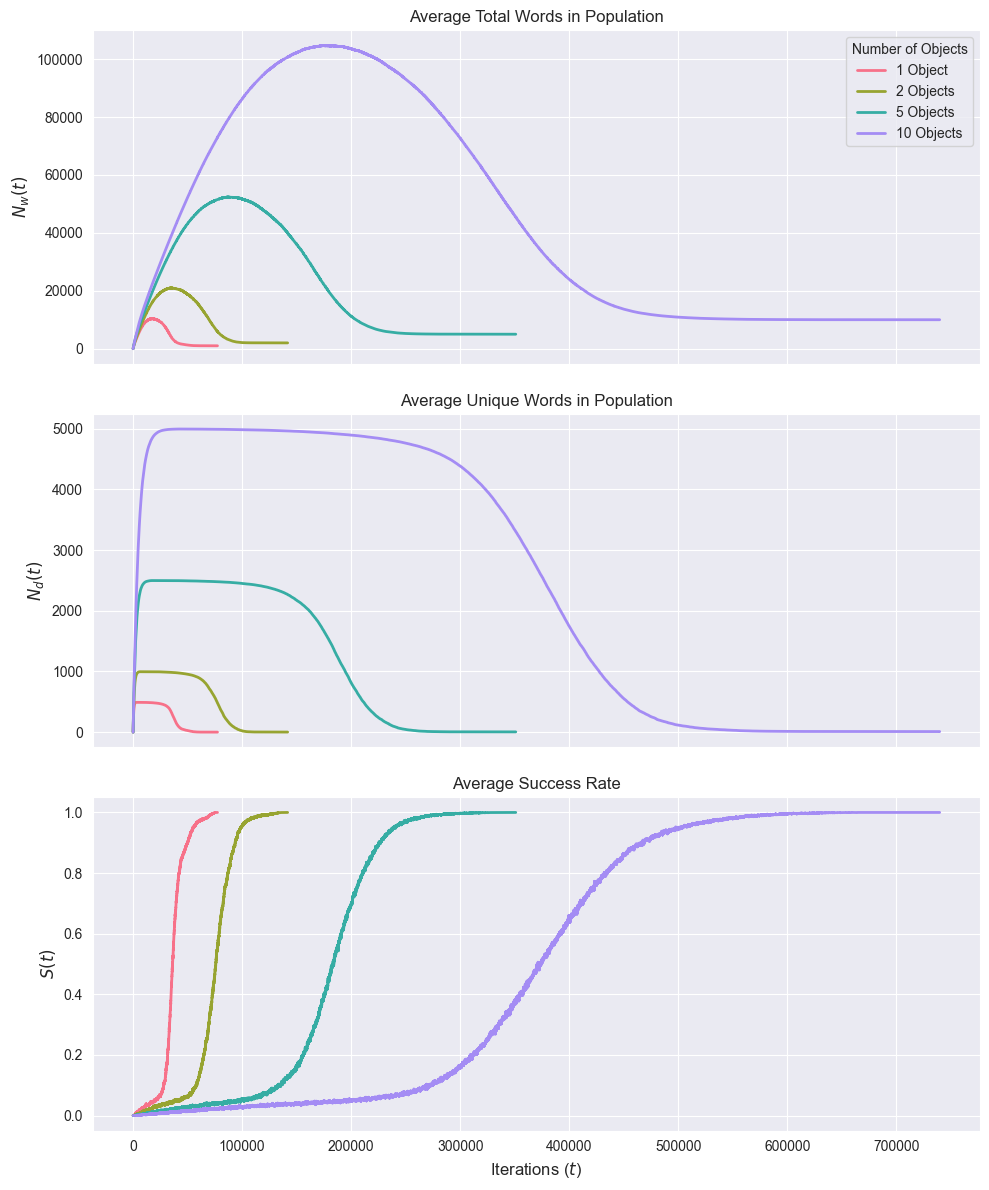

In [9]:
# Group your generated averages into a dictionary
multi_object_data = {
    1: (avg_nw, avg_nd, avg_s),
    2: (avg_nw_two, avg_nd_two, avg_s_two),
    5: (avg_nw_five, avg_nd_five, avg_s_five),
    10: (avg_nw_ten, avg_nd_ten, avg_s_ten)
}

# Plot them together
plot_multiple_objects_averages(multi_object_data)